#### Настройка окружения

In [1]:
%pip install numpy pandas scipy sdv matplotlib gensim scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA

In [3]:
%pip install summa nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from summa import summarizer
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alexa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Предобучение модели векторизации

In [5]:
from gensim.models.fasttext import FastText
from gensim.test.utils import datapath

VECTOR_SIZE = 300

corpus_file = datapath('lee_background.cor')

model = FastText(vector_size=VECTOR_SIZE)
model.build_vocab(corpus_file=corpus_file)
model.train(
    corpus_file=corpus_file, epochs=model.epochs,
    total_examples=model.corpus_count, total_words=model.corpus_total_words,
)

with open("../fasttext_lee_background", "w+") as file:
    model.save(file.name)

## Загрузка, предобработка и выделение тестовой выборки для реализации методов

In [6]:
df = pd.read_csv('../test.csv')
df.head()

,id,article,highlights
0,92c514c913c0bdfe25341af9fd72b29db544099b,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,2003841c7dc0e7c5b1a248f9cd536d727f27a45a,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,91b7d2311527f5c2b63a65ca98d21d9c92485149,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,caabf9cbdf96eb1410295a673e953d304391bfbb,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,3da746a7d9afcaa659088c8366ef6347fe6b53ea,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."


In [7]:
df = df.iloc[:, 1:]
df.dropna()
df

,article,highlights
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."
...,...,...
11485,Our young Earth may have collided with a body ...,Oxford scientists say a Mercury-like body stru...
11486,A man facing trial for helping his former love...,Man accused of helping former lover kill woman...
11487,A dozen or more metal implements are arranged ...,Marianne Power tried the tuning fork facial at...
11488,Brook Lopez dominated twin brother Robin with ...,Brooklyn Nets beat the Portland Trail Blazers ...


In [8]:
df_sample = df.sample(n=100, random_state=42)
df_sample

,article,highlights
1516,Comedian Jenny Eclair travelled with her other...,The comedian stayed with Flavours who offer a ...
1393,A woman of Arab and Jewish descent who was str...,The federal government will give Shoshana Hebs...
10560,World No 1 Novak Djokovic has apologised to th...,Novak Djokovic beat Andy Murray 7-6 4-6 6-0 in...
11457,(CNN)ISIS on Wednesday released more than 200 ...,Most of those released were women and children...
647,Hillary Clinton’s security detail arrived at a...,"Second modified, armored van spotted near Des ..."
...,...,...
1396,(CNN)Novak Djokovic extended his current winni...,Djokovic wins Monte Carlo Masters .\nDefeats B...
9953,Washington (CNN)An off-duty member of the Unif...,Off-duty member of the Uniformed Division of S...
6452,Islamic State militants infiltrated a Palestin...,Jihadis entered the camp through the nearby Ha...
1277,Alan Smith has rubbished claims that Liverpool...,Liverpool beat Manchester United 1-0 in the FA...


### Среднее количество слов (вкл. пунктуацию) и средняя длина текста по колонкам

In [9]:
res_words = {}
res_lengths = {}

for column in df_sample.columns:
    res_words[column] = []
    res_lengths[column] = []

for idx, row in df_sample.iterrows():
    for column in df_sample.columns:
        res_words[column].append(len(row[column].split()))
        res_lengths[column].append(len(row[column]))

res_mean_words = {}
res_mean_length = {}

for column in df_sample.columns:
    res_mean_words[column] = np.mean(res_words[column])
    res_mean_length[column] = np.mean(res_lengths[column])

print(res_mean_words)
print(res_mean_length)

{'article': 656.24, 'highlights': 56.25}
{'article': 3796.2, 'highlights': 318.83}


Исходя из полученных результатов для данного датасета, можно сказать, что подход с 32 токенами не подходит для работы, т.к. из изначальных текстов сохраняется для article около 5% текста, для highlights около 57%. Так как в данной версии работы мы не реализовываем обратную декодировку из векторов в текст и сравниваем лишь векторные представления изначальных и синтетических данных, можно сказать, что такой подход сработает для проверки работоспособности методов. В дальнейшем рекомендуется сделать суммаризацию и больше внимания уделить векторным представлениям изначальных данных.

In [10]:
from gensim.models import FastText
from gensim.utils import simple_preprocess

model = FastText.load("../fasttext_lee_background")


def get_vectorised_entries(entries):
    features = []
    for entry in entries:
        tokens = simple_preprocess(entry)
        vectors = [model.wv[token] for token in tokens]
        features.append(np.mean(vectors, axis=0))
    return np.array(features)

## Векторизация и подсчёт описательных статистик

In [11]:
summary_stats = []
features_data = []

for column in df_sample.columns:
    entries = [x for x in df_sample[column]]
    features = get_vectorised_entries(entries)

    mean = np.mean(features, axis=0)
    standard_deviation = np.std(features, axis=0)
    median = np.median(features, axis=0)
    asymmetry = stats.skew(features, axis=0)
    excess = stats.kurtosis(features, axis=0)

    cov_matrix = np.cov(features.T)
    mean_vector = np.mean(features, axis=0)
    vector_dim = features.shape[1]

    summary_stats.append({
        'column': column,
        'overall_mean': np.mean(mean),
        'overall_std': np.mean(standard_deviation),
        'std_of_means': np.std(mean),
        'mean_of_medians': np.mean(median),
        'asymmetry_avg': np.mean(asymmetry),
        'excess_avg': np.mean(excess),
        'n_entries': len(entries),
        'vector_dim': vector_dim,
        'mean_vector': mean_vector,
        'cov_matrix': cov_matrix,
        'cov_diagonal': np.diag(cov_matrix),
        'cov_trace': np.trace(cov_matrix),
        'cov_det': np.linalg.det(cov_matrix + np.eye(features.shape[1]) * 1e-6),
        'rank': np.linalg.matrix_rank(features),
        'rank_cov': np.linalg.matrix_rank(cov_matrix),
        'features': features
    })

    features_data.append({
        'column': column,
        'features': features
})

summary_df = pd.DataFrame(summary_stats)
summary_df

,column,overall_mean,overall_std,std_of_means,mean_of_medians,asymmetry_avg,excess_avg,n_entries,vector_dim,mean_vector,cov_matrix,cov_diagonal,cov_trace,cov_det,rank,rank_cov,features
0,article,-0.016385,0.006189,0.204318,-0.016437,0.016063,0.322718,100,300,"[-0.012143706, 0.13611192, -0.20113708, 0.1081...","[[1.8567673671147125e-07, -2.2000394675725598e...","[1.8567673671147125e-07, 2.7341704175175555e-0...",0.018463,0.0,14,99,"[[-0.011846013, 0.13265193, -0.19604798, 0.105..."
1,highlights,-0.015577,0.012887,0.194171,-0.015542,0.043818,0.968801,100,300,"[-0.011617853, 0.12933862, -0.19115293, 0.1027...","[[9.620950665639088e-07, -1.0517327569996145e-...","[9.620950665639088e-07, 0.00011805501146406694...",0.080067,0.0,56,99,"[[-0.011684589, 0.12718932, -0.18812251, 0.101..."


In [27]:
features_data

[{'column': 'article',
  'features': array([[-0.01184601,  0.13265193, -0.19604798, ...,  0.13017157,
           0.01464048, -0.06484886],
         [-0.01227733,  0.13739282, -0.20306292, ...,  0.13467093,
           0.0151655 , -0.06718764],
         [-0.01209298,  0.13667865, -0.20182782, ...,  0.13414492,
           0.01504679, -0.06675973],
         ...,
         [-0.01229716,  0.1361079 , -0.20117936, ...,  0.1337362 ,
           0.01498239, -0.06663349],
         [-0.01163841,  0.13052174, -0.19288345, ...,  0.12809095,
           0.01439205, -0.0638073 ],
         [-0.01167131,  0.13071601, -0.19297466, ...,  0.12837662,
           0.01437506, -0.06396417]], dtype=float32)},
 {'column': 'highlights',
  'features': array([[-0.01168459,  0.12718932, -0.18812251, ...,  0.1249615 ,
           0.01416878, -0.06248036],
         [-0.01137673,  0.1286383 , -0.19047132, ...,  0.12613143,
           0.01426558, -0.06297371],
         [-0.01180052,  0.1319895 , -0.19474149, ...,  0.129395

## Генерация синтетических векторов

In [19]:
def generate_synthetic_vectors(summary_df, method, n_components=None, alpha=0.1):
    synthetic_data = []

    for i, row in summary_df.iterrows():
        print(f"{i}: {row['column']}")
        n_samples = row['n_entries']
        vector_dim = row['vector_dim']

        if method == 'normal':
            mean_vec = np.full(vector_dim, row['overall_mean'])
            cov_matrix = np.eye(vector_dim) * (row['std_of_means'] ** 2)
            synthetic_vectors = stats.multivariate_normal.rvs(
                mean=mean_vec,
                cov=cov_matrix,
                size=n_samples
            )

        elif method == 'statistical_adjustment':
            base_vectors = np.random.normal(
                loc=row['overall_mean'],
                scale=row['overall_std'],
                size=(n_samples, vector_dim)
            )
            synthetic_vectors = adjust_statistics(
                base_vectors,
                target_mean=row['overall_mean'],
                target_std=row['overall_std']
            )

        elif method == 'covariance_based':
            mean_vector = row['mean_vector']
            cov_matrix = row['cov_matrix']
            trace = np.trace(cov_matrix)
            if trace > 0:
                reg_param = alpha * trace / vector_dim
            else:
                reg_param = alpha
            cov_regularized = cov_matrix + np.eye(vector_dim) * reg_param

            synthetic_vectors = stats.multivariate_normal.rvs(
                mean=mean_vector,
                cov=cov_regularized,
                size=n_samples
            )

        elif method == 'covariance_pca':
            mean_vector = row['mean_vector']
            features = row['features']
            pca_test = PCA()
            pca_test.fit(features)
            explained_variance = np.cumsum(pca_test.explained_variance_ratio_)

            if n_components is None:
                min_comp = 2
                max_comp = np.where(explained_variance >= 0.95)[0]
                if len(max_comp) > 0:
                    target_comp = max_comp[0] + 1
                else:
                    target_comp = len(features) - 1
                n_components_final = max(min_comp, min(target_comp, len(features)-1))
            else:
                n_components_final = min(n_components, len(features)-1)

            n_components_final = max(2, n_components_final)
            pca = PCA(n_components=n_components_final)
            features_pca = pca.fit_transform(features)
            pca_dim = features_pca.shape[1]
            if pca_dim == 1:
                features_pca = np.hstack([features_pca, np.zeros((len(features), 1))])
                pca.components_ = np.vstack([pca.components_, np.zeros(300)])
                pca_dim = 2
            mean_pca = np.mean(features_pca, axis=0)
            cov_pca = np.cov(features_pca.T)
            cov_pca_reg = cov_pca + np.eye(pca_dim) * 1e-8

            synthetic_pca = stats.multivariate_normal.rvs(
                mean=mean_pca,
                cov=cov_pca_reg,
                size=n_samples
            )

            synthetic_vectors = pca.inverse_transform(synthetic_pca)

        elif method == 'covariance_lw':
            mean_vector = row['mean_vector']
            features = row['features']
            lw = LedoitWolf()
            lw.fit(features)
            cov_lw = lw.covariance_

            synthetic_vectors = stats.multivariate_normal.rvs(
                mean=mean_vector,
                cov=cov_lw,
                size=n_samples
            )

        else:
            raise ValueError(f"Unknown method: {method}")

        synthetic_data.append({
            'column': row['column'],
            'method': method,
            'vectors': synthetic_vectors,
            'original_stats': {
                'n_entries': row['n_entries'],
                'vector_dim': row['vector_dim'],
                'overall_mean': row['overall_mean'],
                'overall_std': row['overall_std'],
                'mean_vector': row['mean_vector'],
                'asymmetry_avg': row['asymmetry_avg'],
                'excess_avg': row['excess_avg'],
                'cov_matrix': row['cov_matrix'],
                'rank': row['rank'],
                'rank_cov': row['rank_cov']
            }
        })

    return synthetic_data


def adjust_statistics(vectors, target_mean, target_std):
    vectors = vectors - np.mean(vectors, axis=0)
    current_std = np.std(vectors, axis=0)
    vectors = vectors * (target_std / current_std)
    vectors = vectors + target_mean
    return vectors

## Проверка корректности и графики

In [20]:
def validate_synthetic_data(synthetic_data):
    validation_results = []

    for data in synthetic_data:
        original_stats = data['original_stats']
        synthetic_vectors = np.asarray(data['vectors'])
        synth_mean = np.mean(synthetic_vectors, axis=0)
        synth_std = np.std(synthetic_vectors, axis=0)
        synth_skew = stats.skew(synthetic_vectors, axis=0)
        synth_kurt = stats.kurtosis(synthetic_vectors, axis=0)
        synth_mean_avg = np.mean(synth_mean)
        synth_std_avg = np.mean(synth_std)
        synth_skew_avg = np.mean(synth_skew)
        synth_kurt_avg = np.mean(synth_kurt)

        validation_results.append({
            'column': data['column'],
            'method': data.get('method', 'unknown'),
            'mean_error': abs(synth_mean_avg - original_stats['overall_mean']),
            'std_error': abs(synth_std_avg - original_stats['overall_std']),
            'skew_error': abs(synth_skew_avg - original_stats['asymmetry_avg']),
            'kurt_error': abs(synth_kurt_avg - original_stats['excess_avg']),
            'original_mean': original_stats['overall_mean'],
            'original_std': original_stats['overall_std'],
            'original_skew': original_stats['asymmetry_avg'],
            'original_kurt': original_stats['excess_avg'],
            'synthetic_mean': synth_mean_avg,
            'synthetic_std': synth_std_avg,
            'synthetic_skew': synth_skew_avg,
            'synthetic_kurt': synth_kurt_avg,
            'n_samples': len(synthetic_vectors),
            'vector_dim': original_stats['vector_dim']
        })

    return pd.DataFrame(validation_results)


def visualize_distributions(synthetic_data, features_data, column_name=None, n_dimensions=5, use_pca=True):
    if column_name:
        synthetic_item = next((item for item in synthetic_data if item['column'] == column_name), None)
        original_item = next((item for item in features_data if item['column'] == column_name), None)
    else:
        synthetic_item = synthetic_data[0] if synthetic_data else None
        original_item = features_data[0] if features_data else None

    if synthetic_item is None or original_item is None:
        print(f"Данные не найдены для колонки: {column_name}")
        return

    original_vectors = np.asarray(original_item['features'])
    synthetic_vectors = np.asarray(synthetic_item['vectors'])
    col_name = synthetic_item['column']

    print(f"Колонка: {col_name}")
    print(f"  Метод генерации: {synthetic_item.get('method', 'unknown')}")
    print(f"  Исходные векторы: {original_vectors.shape}")
    print(f"  Синтетические векторы: {synthetic_vectors.shape}")

    vector_dim = original_vectors.shape[1]
    n_dimensions = min(n_dimensions, vector_dim)
    dim_indices = np.linspace(0, vector_dim - 1, n_dimensions, dtype=int)

    # 1. Гистограммы по отдельным измерениям
    fig, axes = plt.subplots(2, n_dimensions, figsize=(4*n_dimensions, 8))
    if n_dimensions == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(f'Распределения по измерениям: {col_name}', fontsize=14, fontweight='bold')
    for i, dim_idx in enumerate(dim_indices):
        axes[0, i].hist(original_vectors[:, dim_idx], bins=50, alpha=0.7, color='blue',
                       label='Исходные', density=True)
        axes[0, i].set_title(f'Измерение {dim_idx}')
        axes[0, i].set_xlabel('Значение')
        axes[0, i].set_ylabel('Плотность')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        axes[1, i].hist(synthetic_vectors[:, dim_idx], bins=50, alpha=0.7, color='red',
                       label='Синтетические', density=True)
        axes[1, i].set_title(f'Измерение {dim_idx}')
        axes[1, i].set_xlabel('Значение')
        axes[1, i].set_ylabel('Плотность')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Совмещенные гистограммы
    n_compare = min(3, n_dimensions)
    fig, axes = plt.subplots(1, n_compare, figsize=(5*n_compare, 4))
    if n_compare == 1:
        axes = [axes]
    fig.suptitle(f'Сравнение распределений: {col_name}', fontsize=14, fontweight='bold')
    for i, dim_idx in enumerate(dim_indices[:n_compare]):
        axes[i].hist(original_vectors[:, dim_idx], bins=50, alpha=0.6, color='blue',
                    label='Исходные', density=True)
        axes[i].hist(synthetic_vectors[:, dim_idx], bins=50, alpha=0.6, color='red',
                    label='Синтетические', density=True)
        axes[i].set_title(f'Измерение {dim_idx}')
        axes[i].set_xlabel('Значение')
        axes[i].set_ylabel('Плотность')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3. Распределение статистик по измерениям
    orig_mean = np.mean(original_vectors, axis=0)
    orig_std = np.std(original_vectors, axis=0)
    orig_skew = stats.skew(original_vectors, axis=0)
    orig_kurt = stats.kurtosis(original_vectors, axis=0)
    synth_mean = np.mean(synthetic_vectors, axis=0)
    synth_std = np.std(synthetic_vectors, axis=0)
    synth_skew = stats.skew(synthetic_vectors, axis=0)
    synth_kurt = stats.kurtosis(synthetic_vectors, axis=0)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Распределение статистик по измерениям: {col_name}',
                 fontsize=14, fontweight='bold')
    stats_data = [
        (orig_mean, synth_mean, 'Среднее'),
        (orig_std, synth_std, 'Стандартное отклонение'),
        (orig_skew, synth_skew, 'Асимметрия'),
        (orig_kurt, synth_kurt, 'Эксцесс')
    ]
    for idx, (orig_stat, synth_stat, label) in enumerate(stats_data):
        ax = axes[idx // 2, idx % 2]
        ax.hist(orig_stat, bins=50, alpha=0.6, color='blue',
               label='Исходные', density=True)
        ax.hist(synth_stat, bins=50, alpha=0.6, color='red',
               label='Синтетические', density=True)
        ax.set_title(label)
        ax.set_xlabel('Значение')
        ax.set_ylabel('Плотность')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4. PCA визуализация
    if use_pca and original_vectors.shape[1] > 2:
        from sklearn.decomposition import PCA
        combined = np.vstack([original_vectors, synthetic_vectors])
        pca = PCA(n_components=2)
        pca.fit(combined)
        orig_2d = pca.transform(original_vectors)
        synth_2d = pca.transform(synthetic_vectors)
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        ax.scatter(orig_2d[:, 0], orig_2d[:, 1], alpha=0.5, s=10,
                  c='blue', label='Исходные', marker='o')
        ax.scatter(synth_2d[:, 0], synth_2d[:, 1], alpha=0.5, s=10,
                  c='red', label='Синтетические', marker='^')
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
        ax.set_title(f'2D проекция через PCA: {col_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # 5. Q-Q plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    orig_sorted = np.sort(orig_mean)
    synth_sorted = np.sort(synth_mean)
    n = len(orig_sorted)
    quantiles = np.linspace(0, 1, min(n, 1000))
    orig_quantiles = np.quantile(orig_sorted, quantiles)
    synth_quantiles = np.quantile(synth_sorted, quantiles)
    ax.scatter(orig_quantiles, synth_quantiles, alpha=0.6, s=20)
    min_val = min(orig_quantiles.min(), synth_quantiles.min())
    max_val = max(orig_quantiles.max(), synth_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеал')
    ax.set_xlabel('Квантили исходных')
    ax.set_ylabel('Квантили синтетических')
    ax.set_title(f'Q-Q Plot средних по измерениям: {col_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

m## Результаты для всех методов

,### Нормальное распределение

0: article
1: highlights
       column  mean_error  std_error  skew_error  kurt_error
0     article    0.001034   0.197409    0.006299    0.402097
1  highlights    0.000304   0.180620    0.027083    1.002379
Колонка: article
  Метод генерации: normal
  Исходные векторы: (100, 300)
  Синтетические векторы: (100, 300)


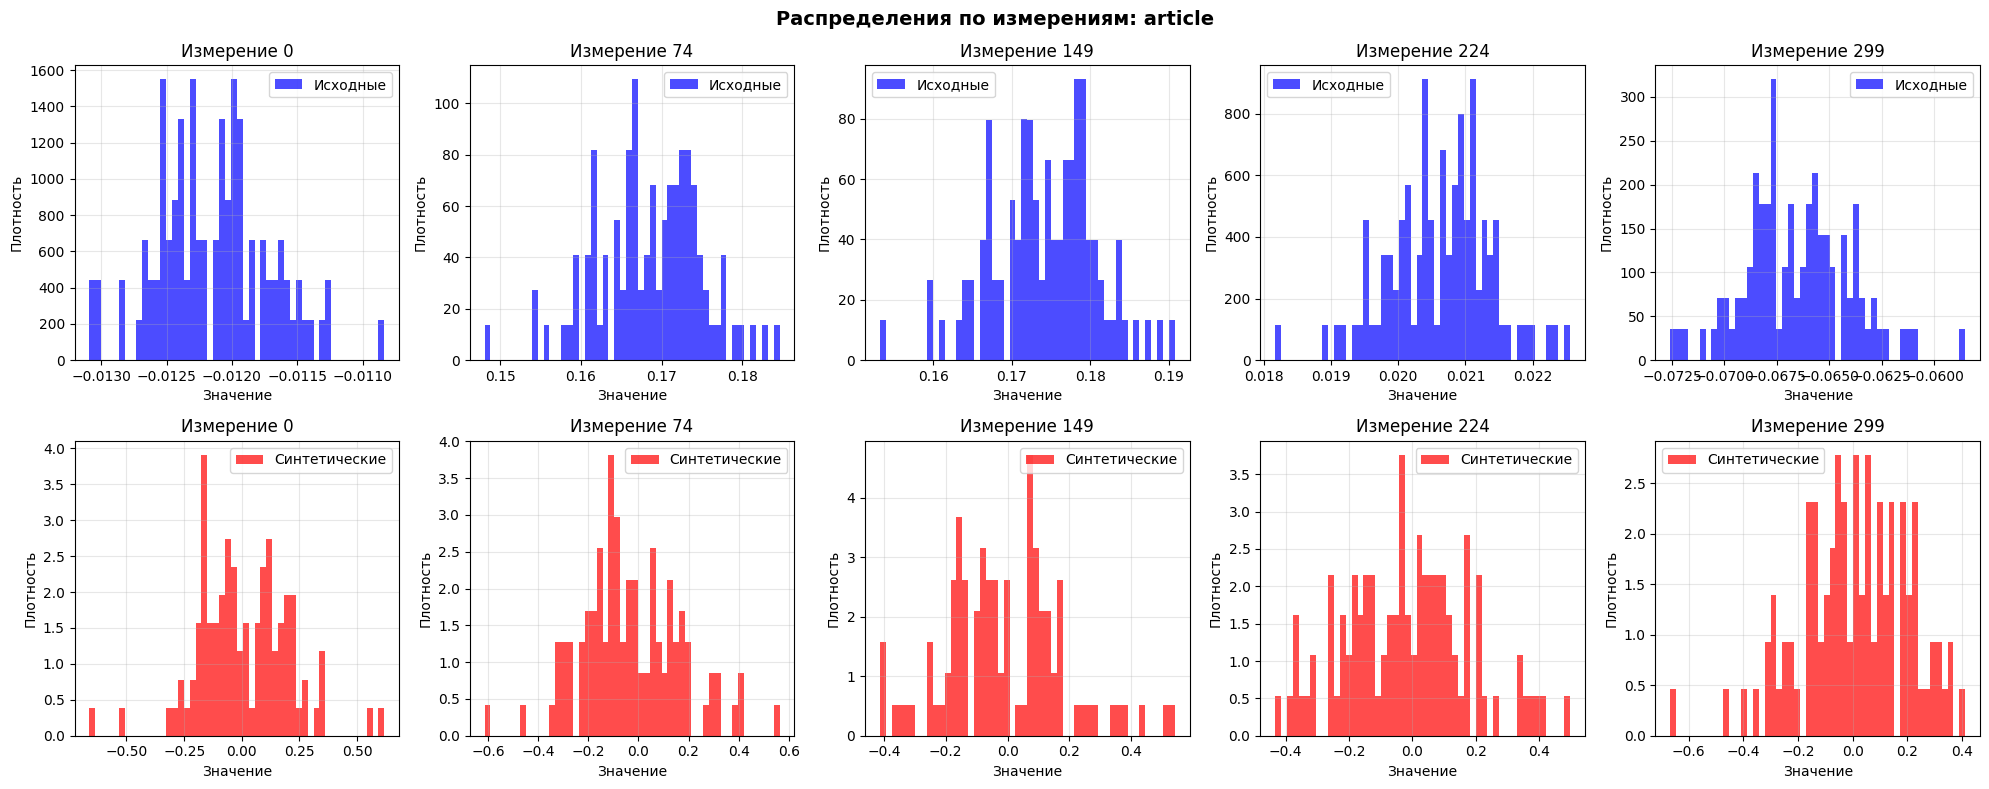

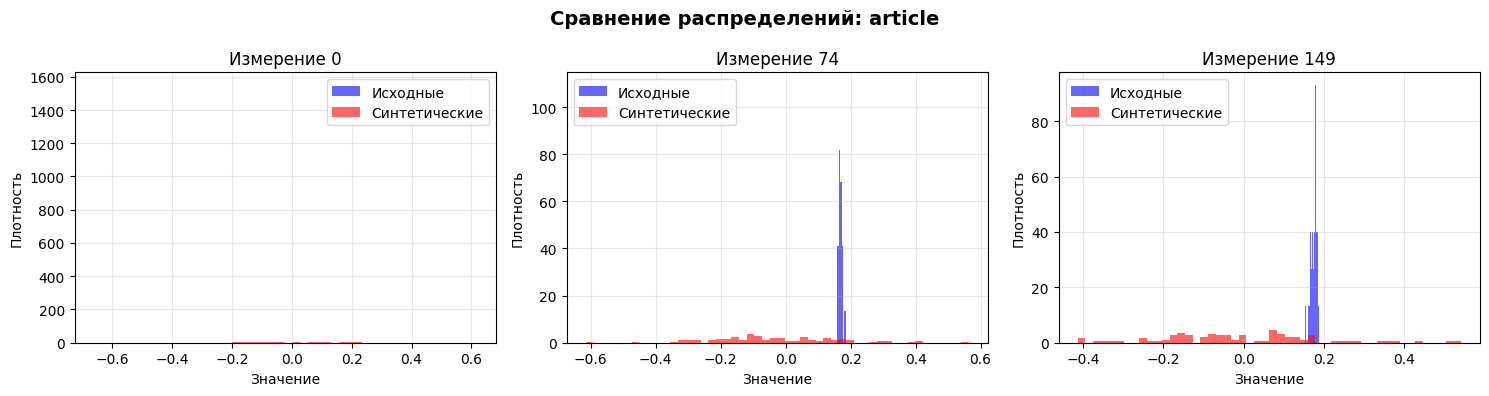

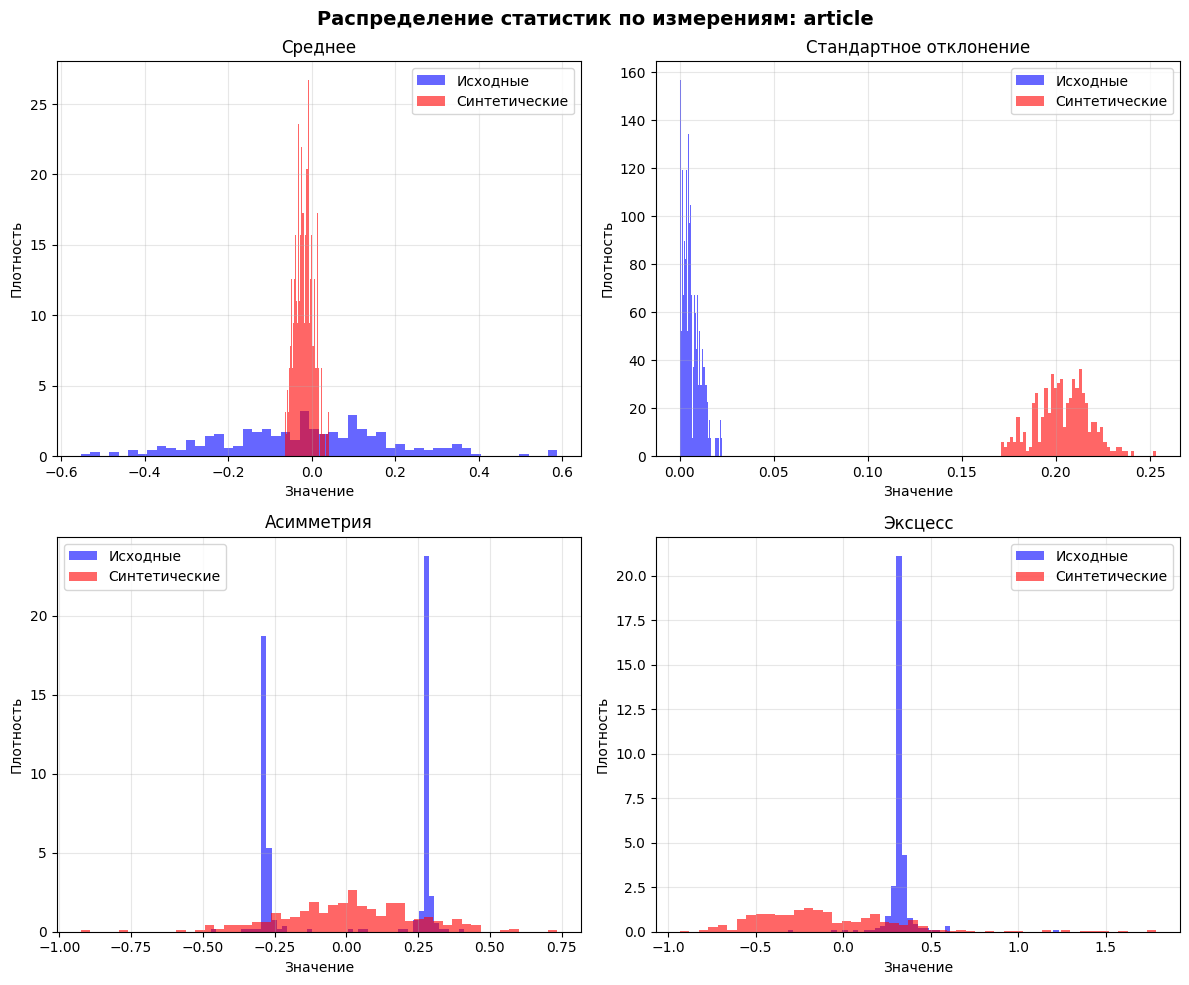

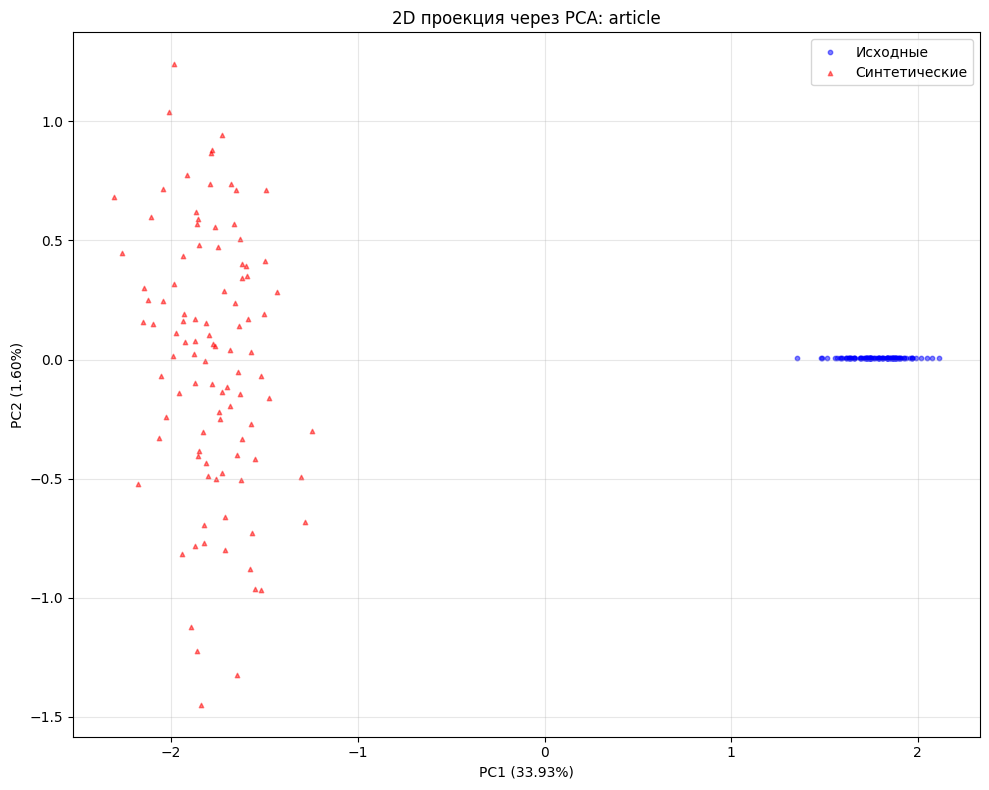

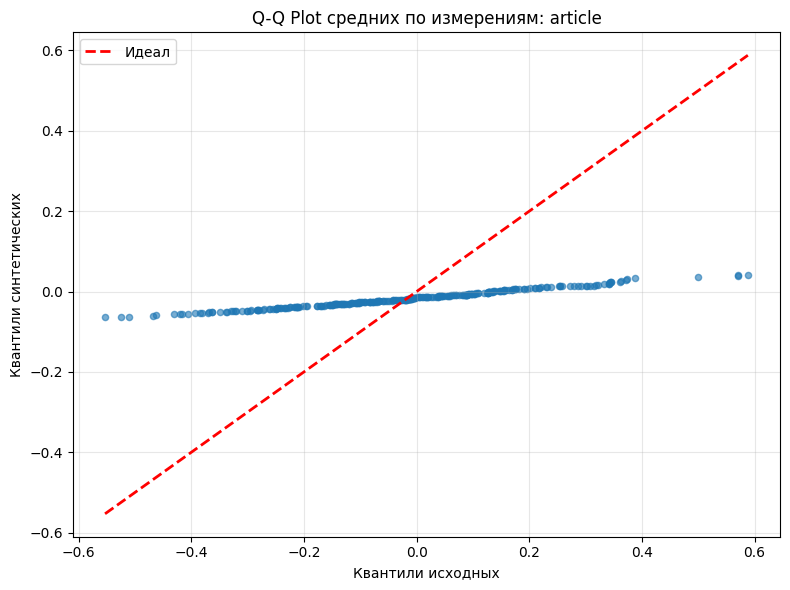

In [21]:
method = 'normal'

try:
    synthetic_data_sa = generate_synthetic_vectors(summary_df, method=method)
    validation_df_sa = validate_synthetic_data(synthetic_data_sa)
    print(validation_df_sa[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])
    visualize_distributions(synthetic_data_sa, features_data,
                           column_name=synthetic_data_sa[0]['column'])

except Exception as e:
    print(f"{e}")
    import traceback
    traceback.print_exc()

### Нормальное распределение со статистической корректировкой

0: article
1: highlights
       column  mean_error  std_error  skew_error  kurt_error
0     article         0.0        0.0    0.028657    0.399950
1  highlights         0.0        0.0    0.033521    1.047687
Колонка: article
  Метод генерации: statistical_adjustment
  Исходные векторы: (100, 300)
  Синтетические векторы: (100, 300)


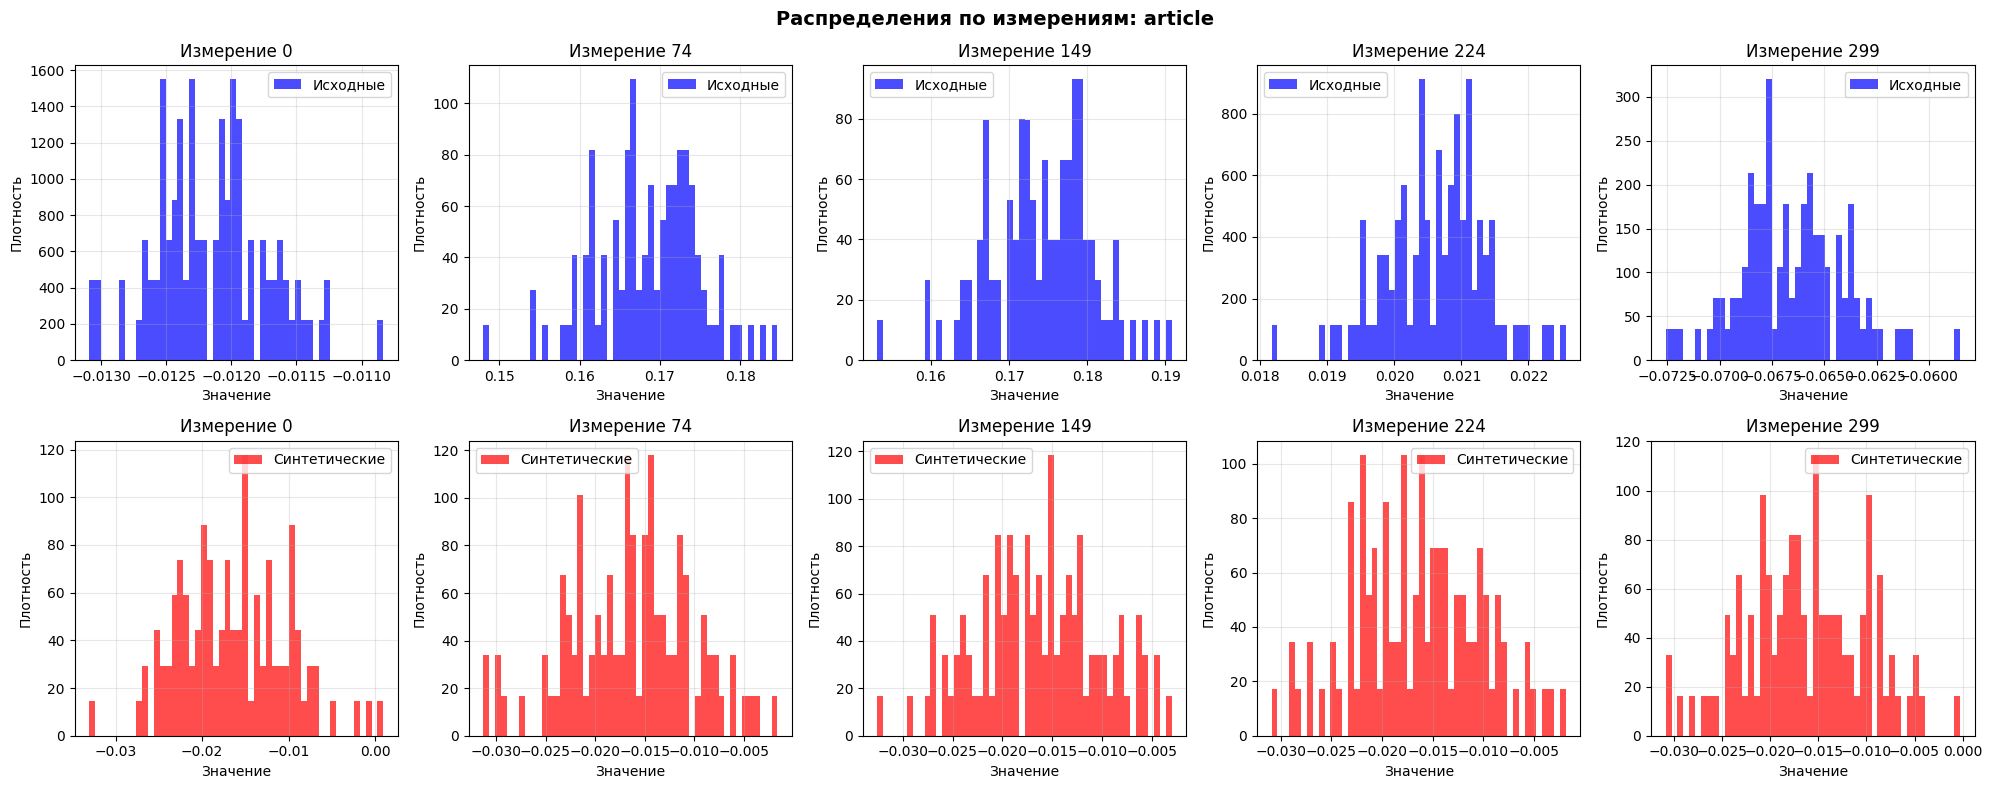

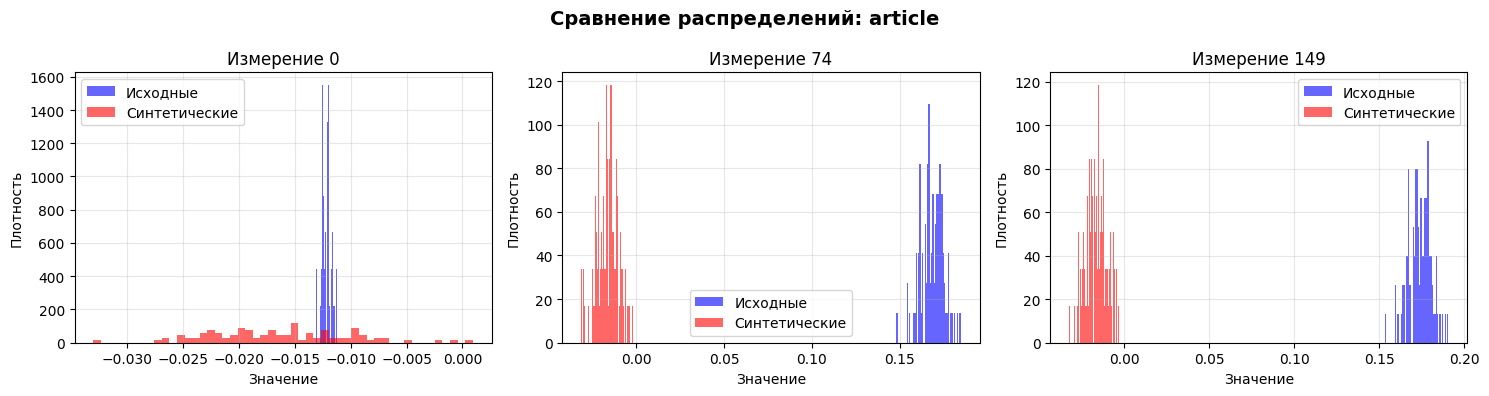

C:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
C:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


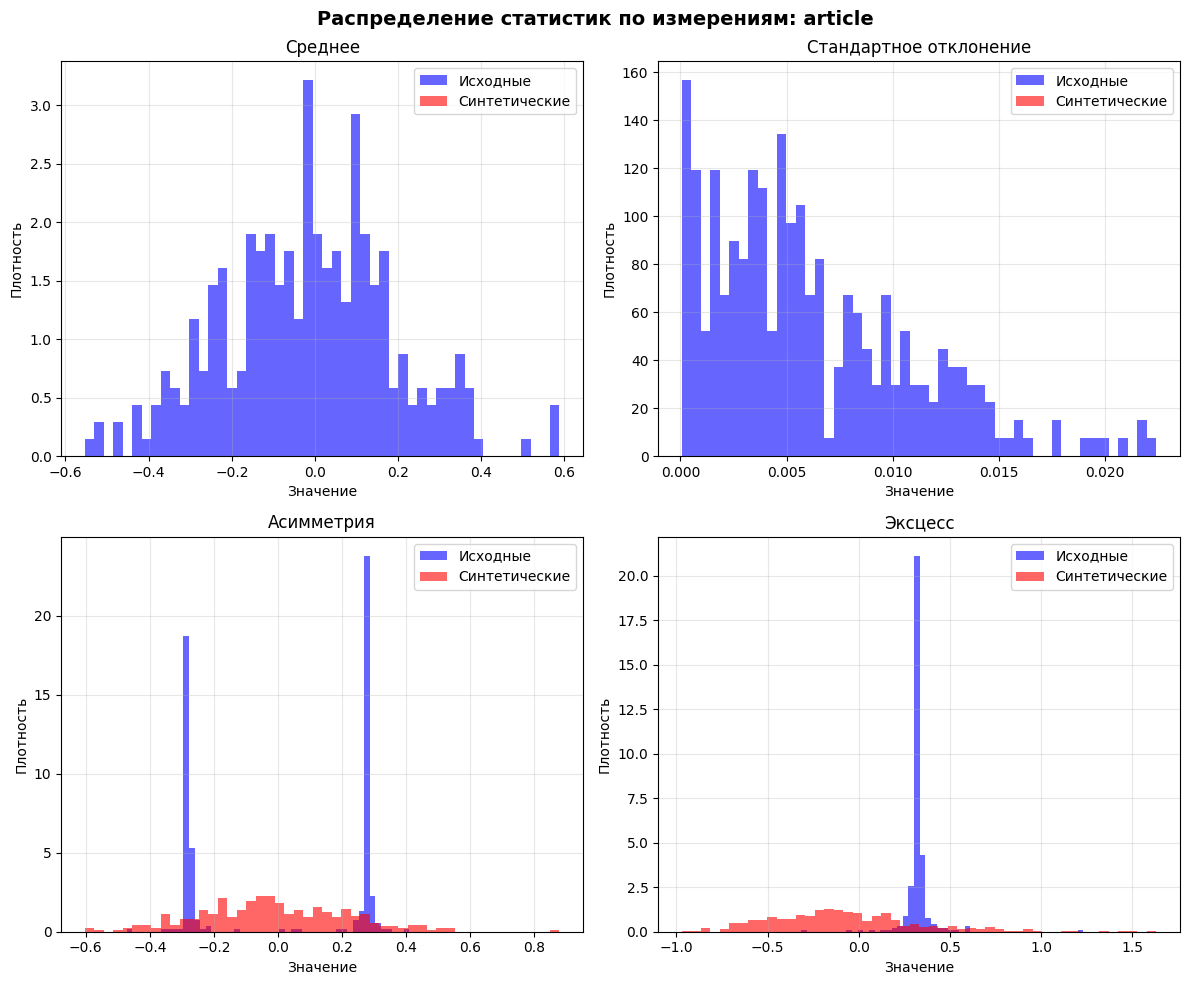

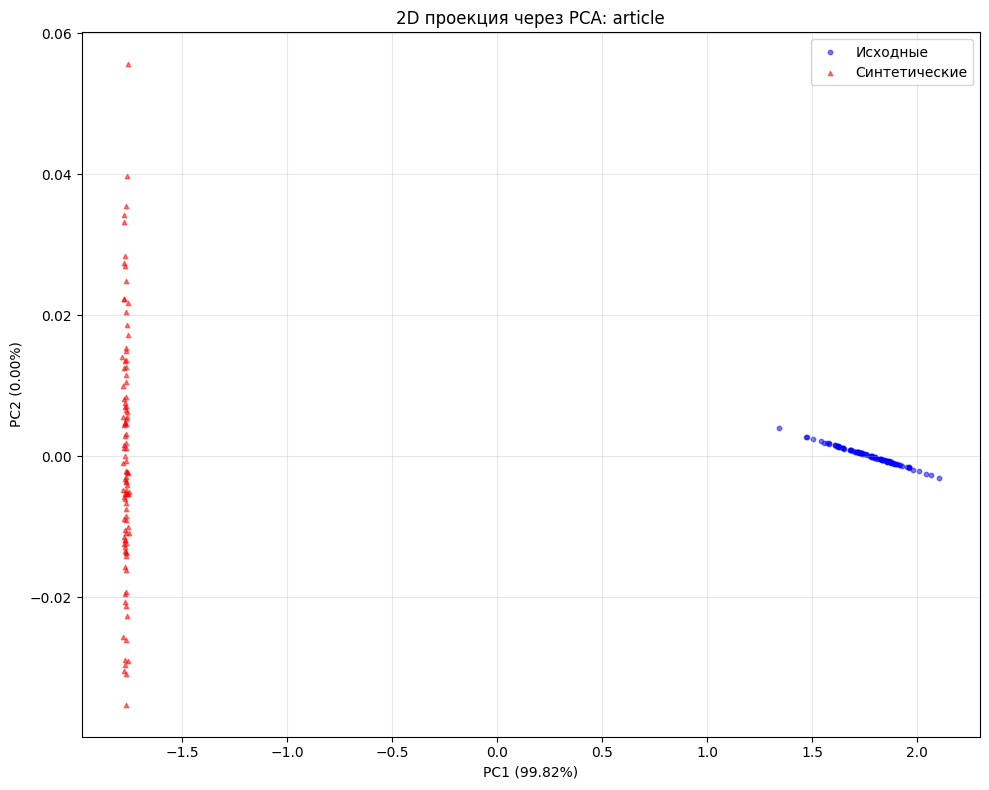

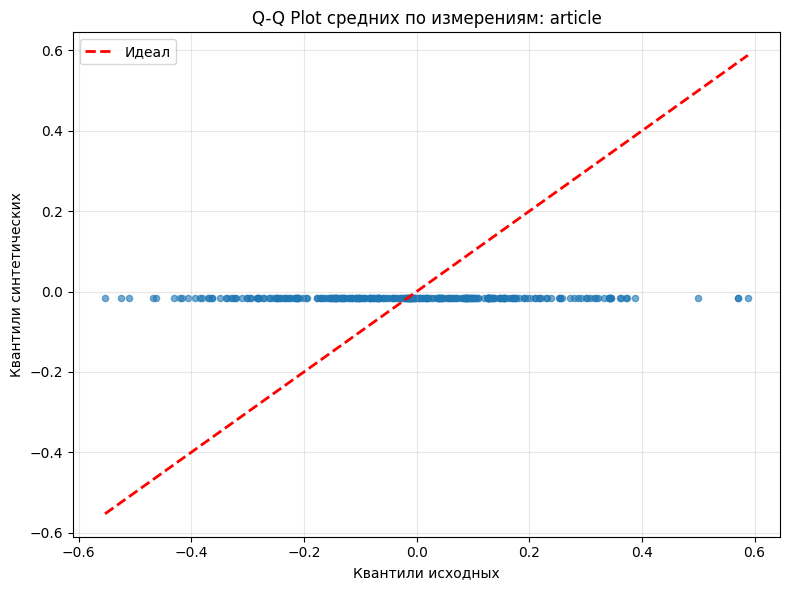

In [22]:
method = 'statistical_adjustment'

try:
    synthetic_data_sa = generate_synthetic_vectors(summary_df, method=method)
    validation_df_sa = validate_synthetic_data(synthetic_data_sa)
    print(validation_df_sa[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])
    visualize_distributions(synthetic_data_sa, features_data,
                           column_name=synthetic_data_sa[0]['column'])

except Exception as e:
    print(f"{e}")
    import traceback
    traceback.print_exc()

In [28]:
synthetic_data_sa

[{'column': 'article',
  'method': 'statistical_adjustment',
  'vectors': array([[-0.01238043, -0.01410256, -0.00141801, ..., -0.01225416,
          -0.0181173 , -0.02058462],
         [-0.01971789, -0.00658443, -0.01942576, ..., -0.01093265,
          -0.00796328, -0.0148995 ],
         [-0.02190837, -0.02472044, -0.01293459, ..., -0.01804117,
          -0.01561577, -0.02087991],
         ...,
         [-0.01382611, -0.02178762, -0.00608241, ..., -0.00959471,
          -0.01983986, -0.01742236],
         [-0.00721818, -0.02199798, -0.02227486, ..., -0.01464102,
          -0.00588673, -0.01786906],
         [-0.01379556, -0.00388815, -0.02271991, ..., -0.02111609,
          -0.02085302, -0.00883368]]),
  'original_stats': {'n_entries': 100,
   'vector_dim': 300,
   'overall_mean': -0.016384953632950783,
   'overall_std': 0.006188706029206514,
   'mean_vector': array([-0.01214371,  0.13611192, -0.20113708,  0.10810757, -0.05299208,
          -0.13161045, -0.1678176 ,  0.3871719 ,  0.321

### С учетом ковариаций

0: article
1: highlights
       column  mean_error  std_error  skew_error  kurt_error
0     article    0.000045   0.000451    0.016572    0.603203
1  highlights    0.000049   0.001149    0.061690    1.172951
Колонка: article
  Метод генерации: covariance_based
  Исходные векторы: (100, 300)
  Синтетические векторы: (100, 300)


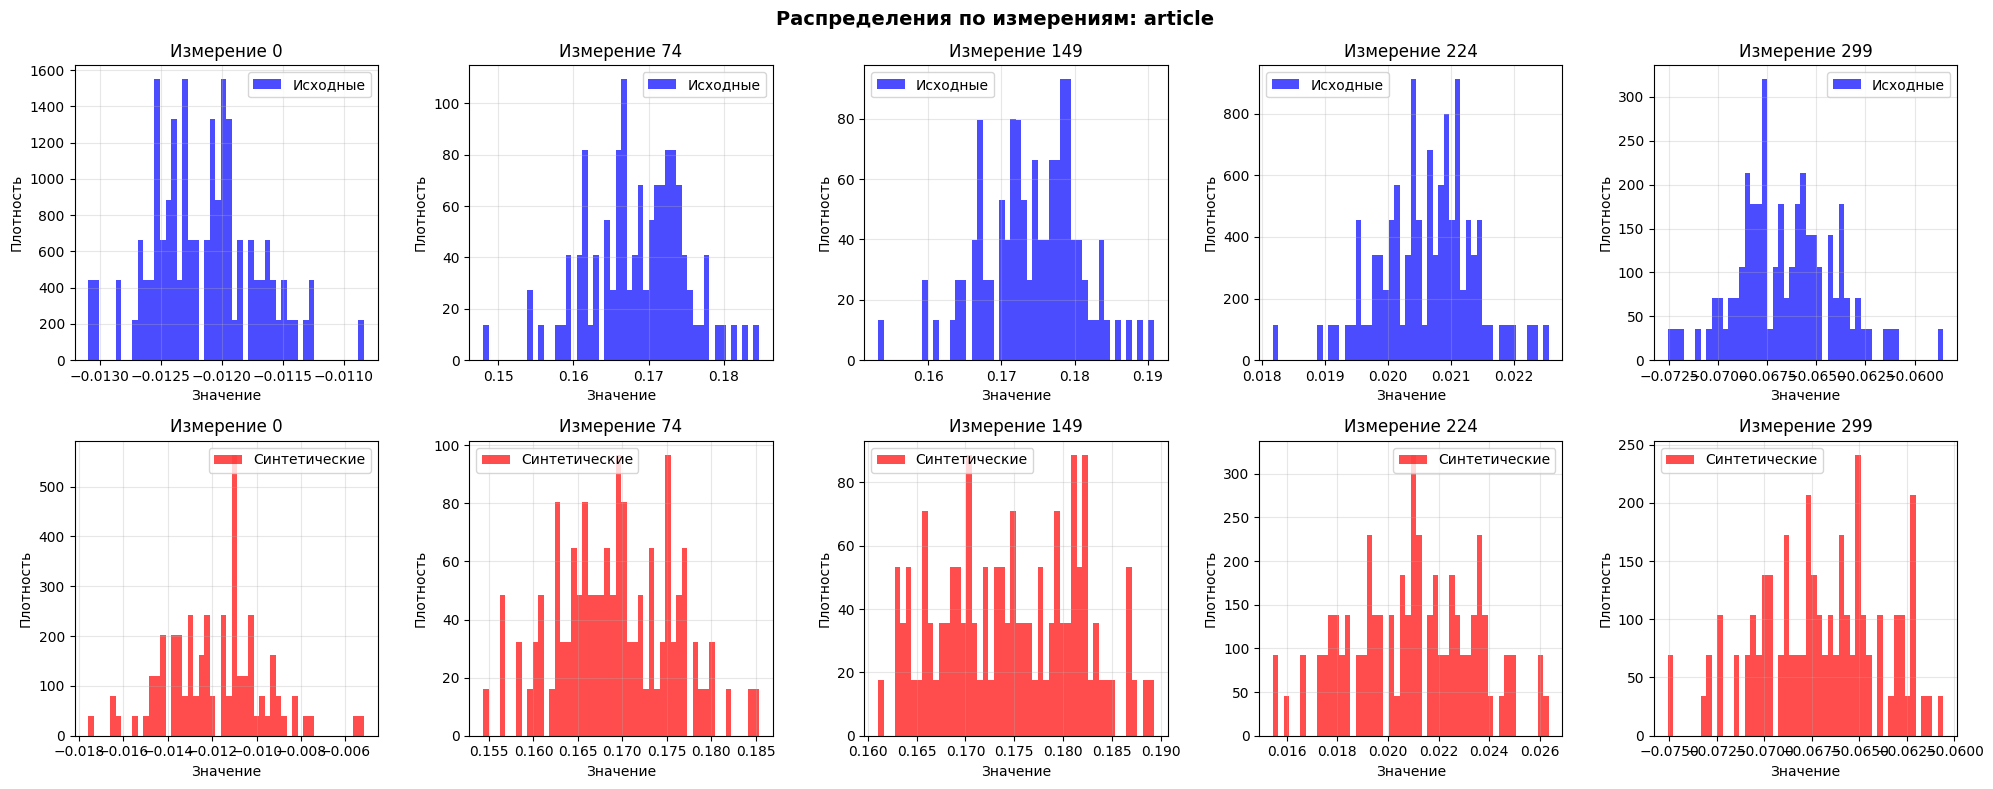

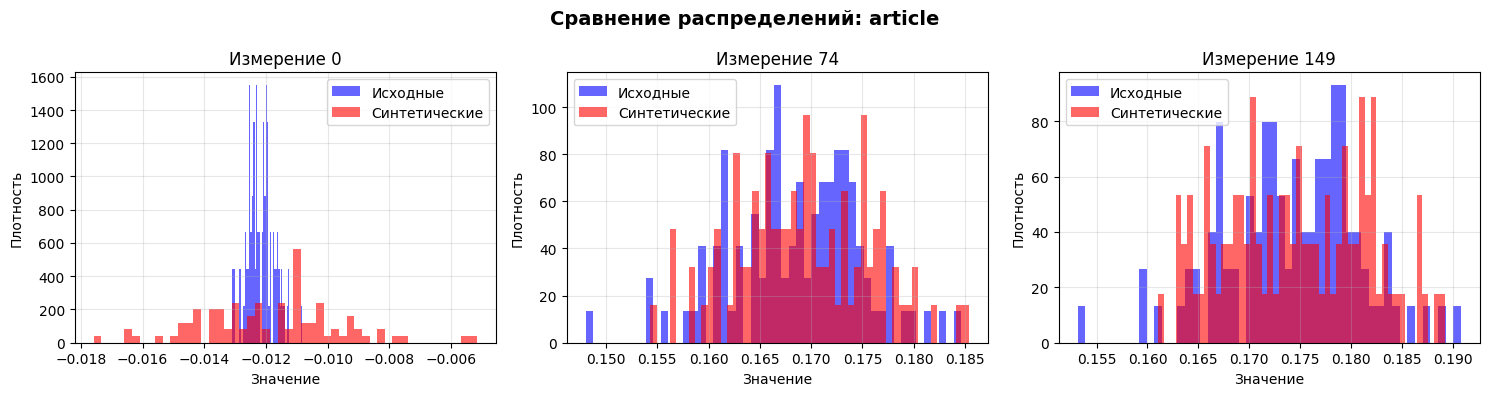

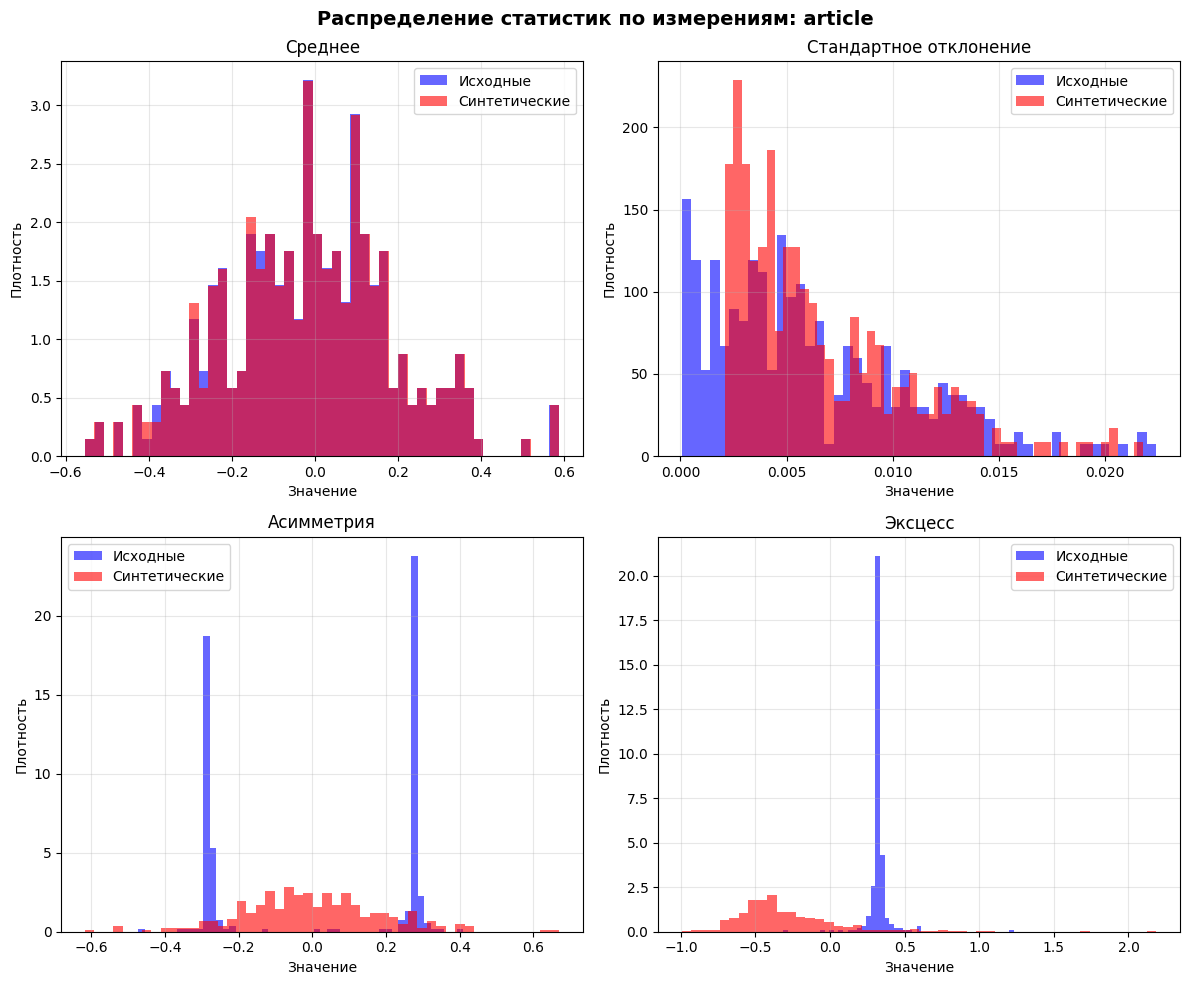

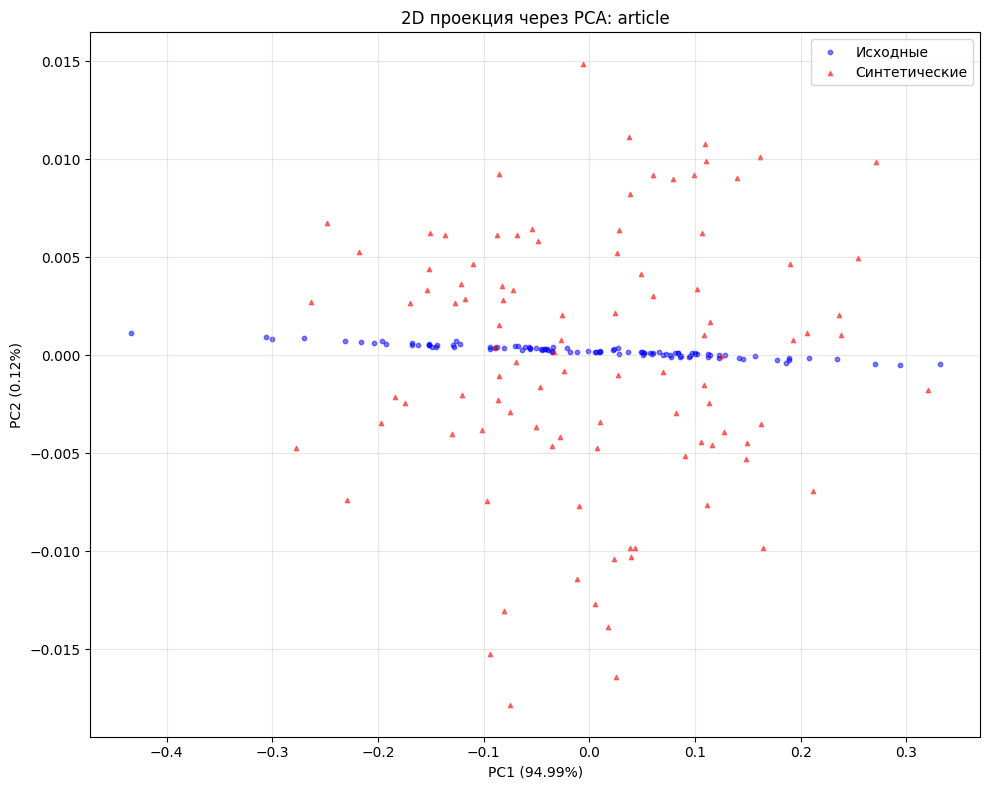

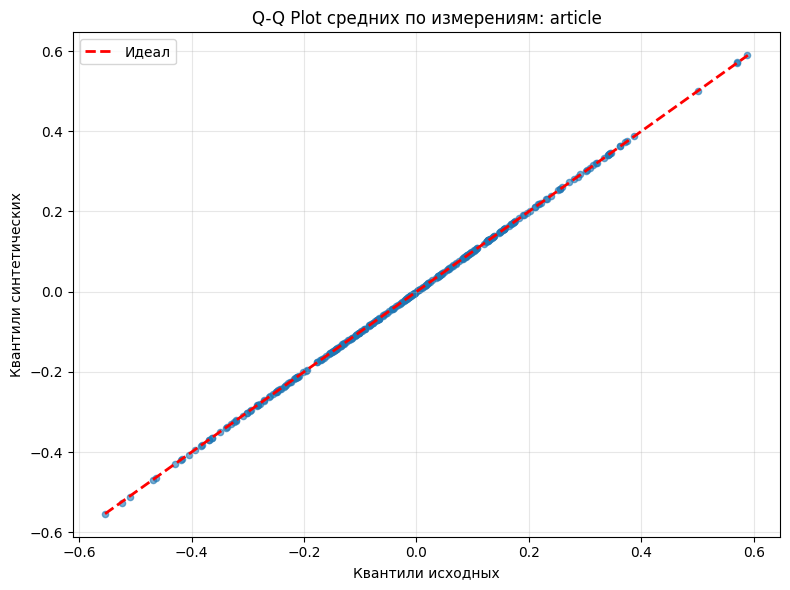

In [31]:
method = 'covariance_based'

try:
    synthetic_data_cov = generate_synthetic_vectors(summary_df, method=method)
    validation_df_cov = validate_synthetic_data(synthetic_data_cov)
    print(validation_df_cov[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])
    visualize_distributions(synthetic_data_cov, features_data,
                           column_name=synthetic_data_cov[0]['column'])

except Exception as e:
    print(f"{e}")
    import traceback
    traceback.print_exc()

In [32]:
synthetic_data_cov

[{'column': 'article',
  'method': 'covariance_based',
  'vectors': array([[-0.0103215 ,  0.1438849 , -0.21115595, ...,  0.14166539,
           0.02196806, -0.07490775],
         [-0.01094293,  0.13974199, -0.20386187, ...,  0.13467395,
           0.01342633, -0.06682899],
         [-0.01142799,  0.12942417, -0.19123486, ...,  0.12738518,
           0.01414764, -0.06446724],
         ...,
         [-0.01221768,  0.12864077, -0.18908403, ...,  0.12548722,
           0.0176021 , -0.06055806],
         [-0.00977028,  0.13373726, -0.19536064, ...,  0.1313666 ,
           0.01566088, -0.07046328],
         [-0.01228553,  0.15126156, -0.21894018, ...,  0.1444127 ,
           0.01495016, -0.07018352]]),
  'original_stats': {'n_entries': 100,
   'vector_dim': 300,
   'overall_mean': -0.016384953632950783,
   'overall_std': 0.006188706029206514,
   'mean_vector': array([-0.01214371,  0.13611192, -0.20113708,  0.10810757, -0.05299208,
          -0.13161045, -0.1678176 ,  0.3871719 ,  0.32149535,

### С учетом ковариаций в пространстве меньшей размерности

0: article
1: highlights
       column  mean_error  std_error  skew_error  kurt_error
0     article    0.000088   0.000208    0.018015     0.58865
1  highlights    0.000165   0.000428    0.036192     1.64985
Колонка: article
  Метод генерации: covariance_pca
  Исходные векторы: (100, 300)
  Синтетические векторы: (100, 300)


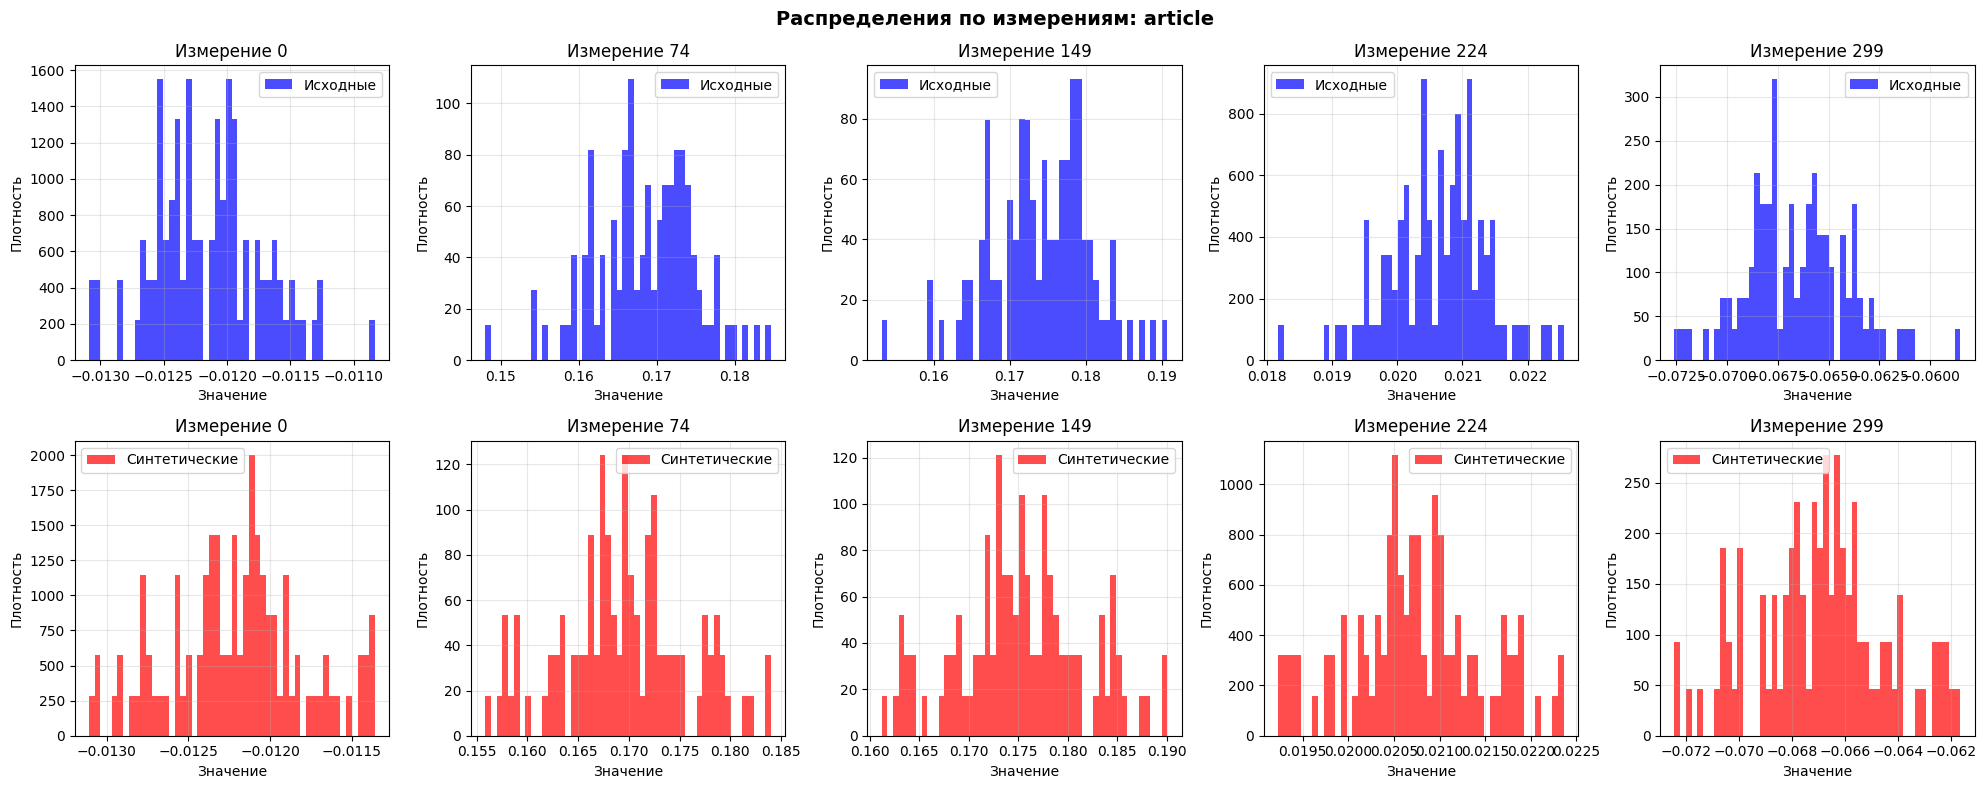

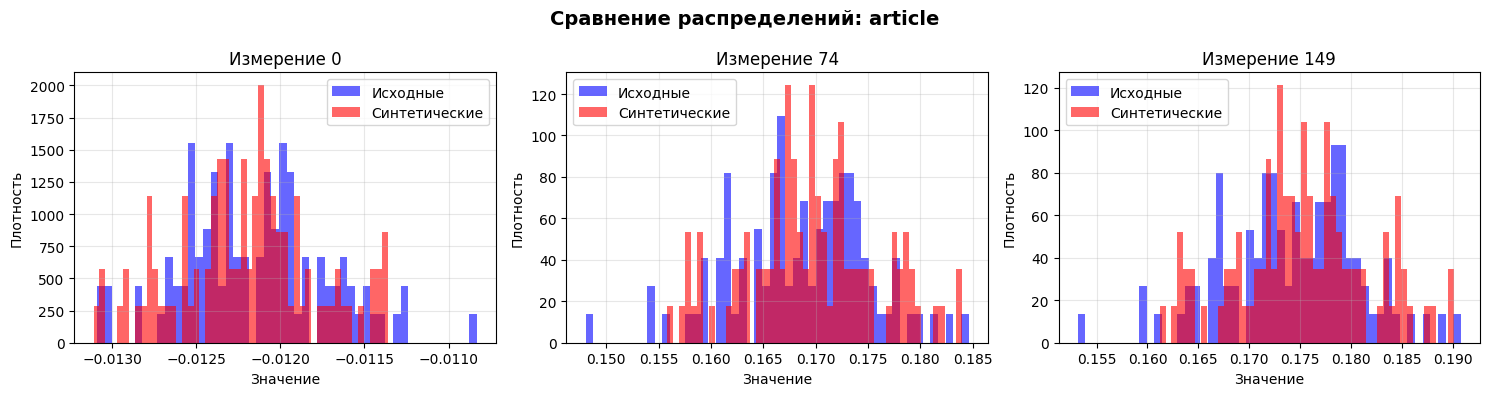

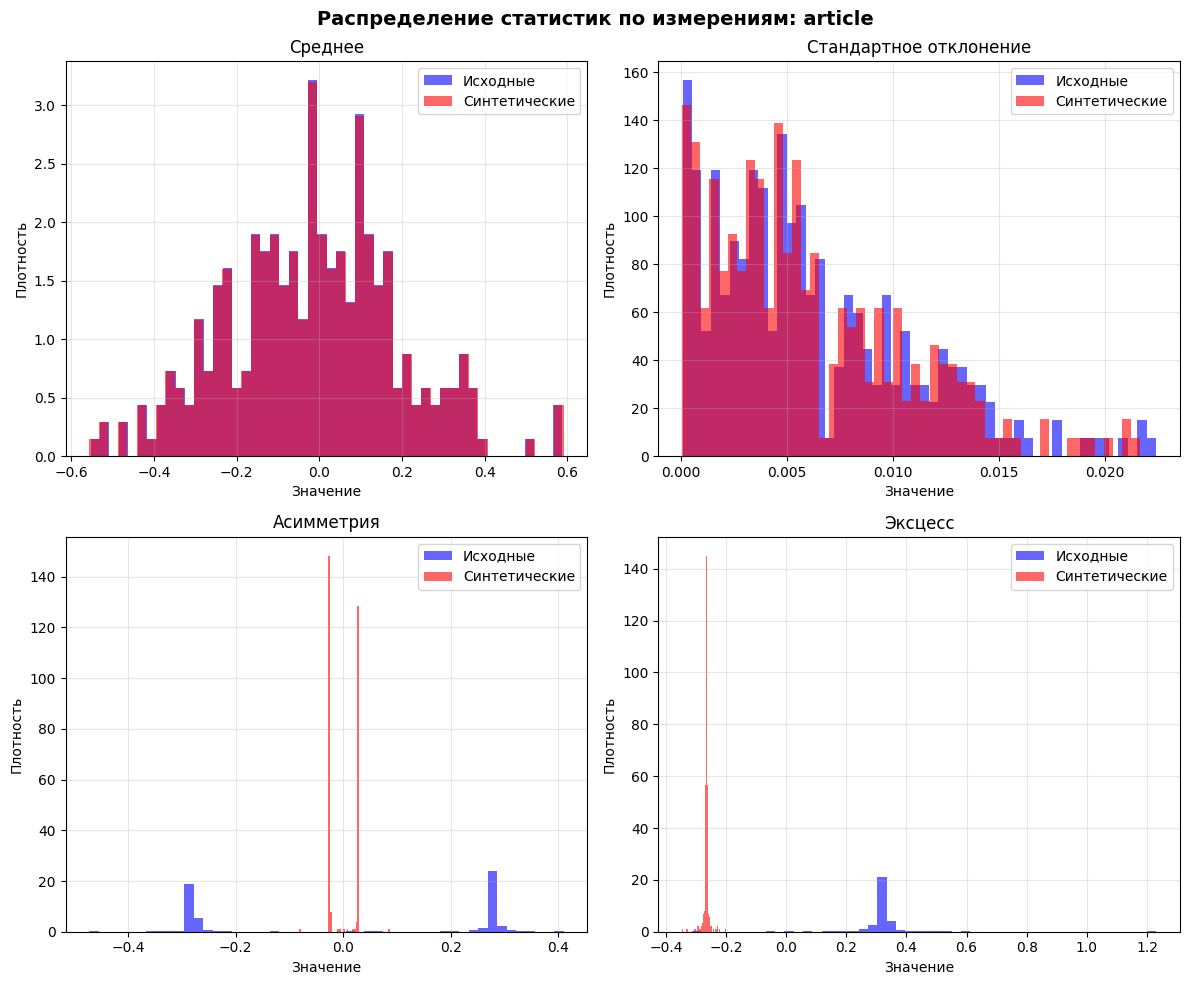

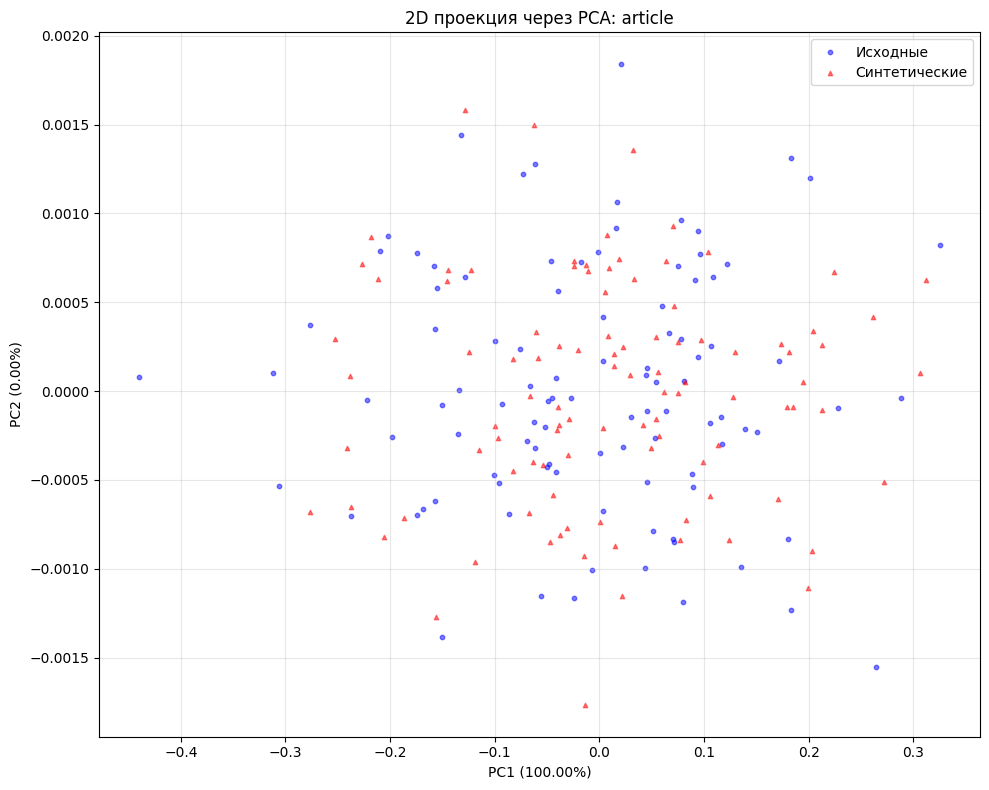

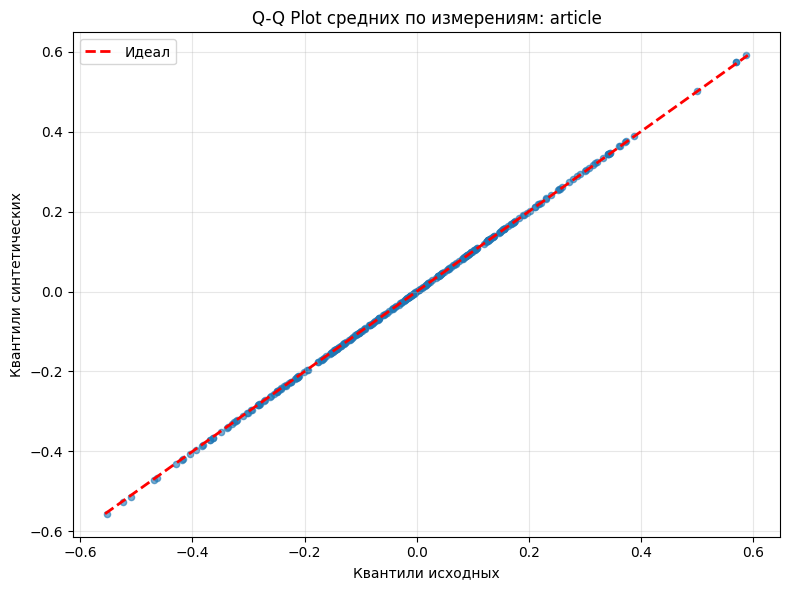

In [24]:
method = 'covariance_pca'

try:
    synthetic_data_cov = generate_synthetic_vectors(summary_df, method=method)
    validation_df_cov = validate_synthetic_data(synthetic_data_cov)
    print(validation_df_cov[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])
    visualize_distributions(synthetic_data_cov, features_data,
                           column_name=synthetic_data_cov[0]['column'])

except Exception as e:
    print(f"{e}")
    import traceback
    traceback.print_exc()

0: article
1: highlights
       column  mean_error  std_error  skew_error  kurt_error
0     article    0.000030   0.000494    0.018422    0.127153
1  highlights    0.000058   0.000136    0.054591    1.026379
Колонка: article
  Метод генерации: covariance_lw
  Исходные векторы: (100, 300)
  Синтетические векторы: (100, 300)


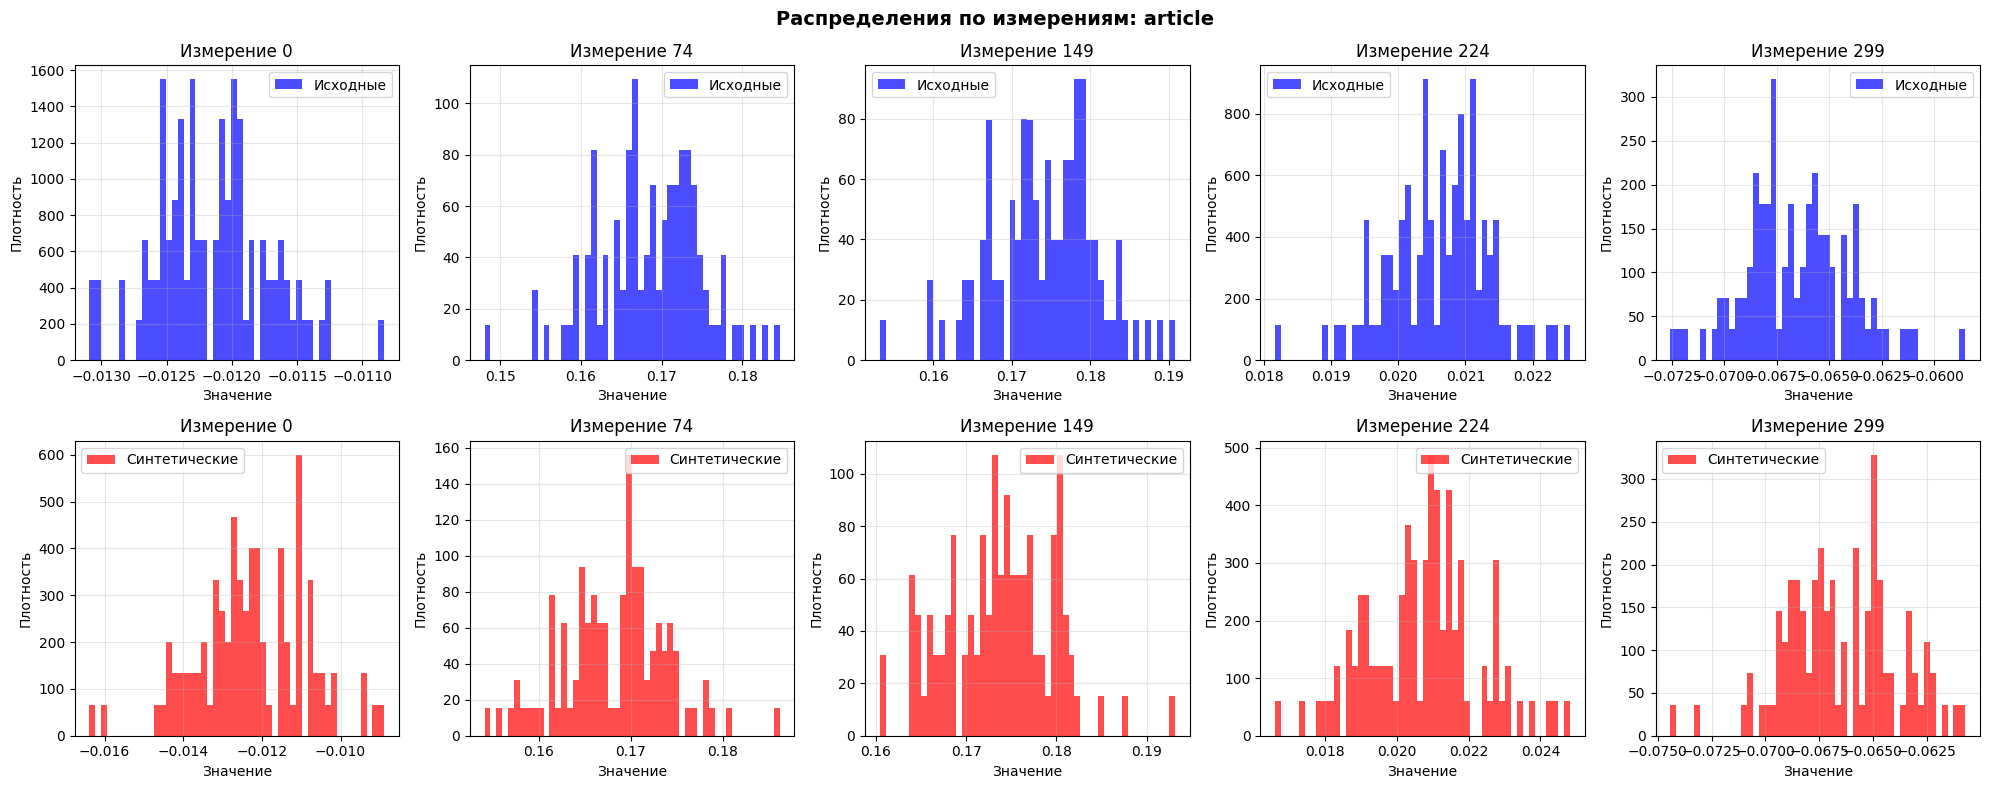

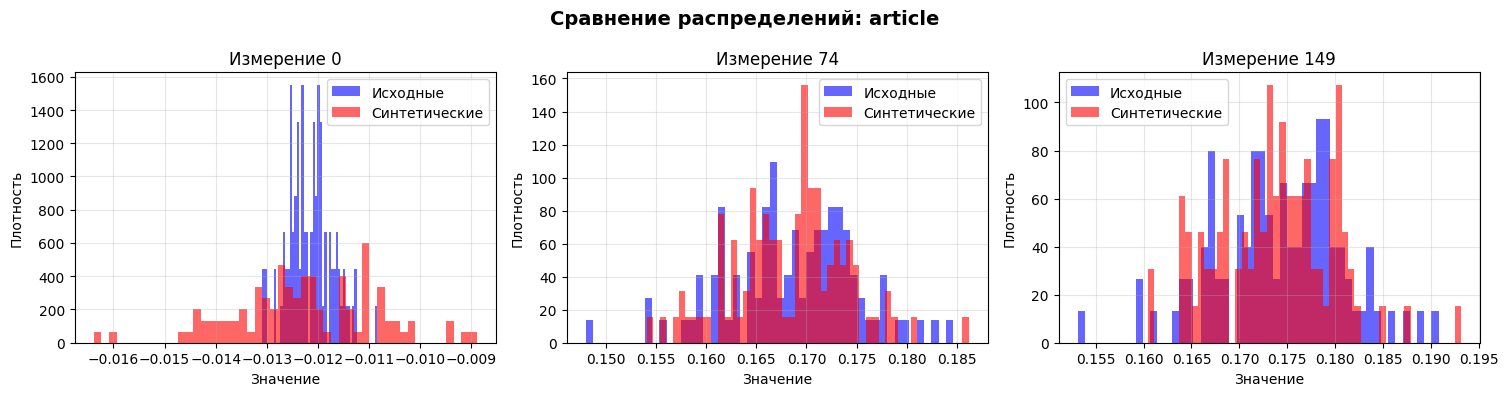

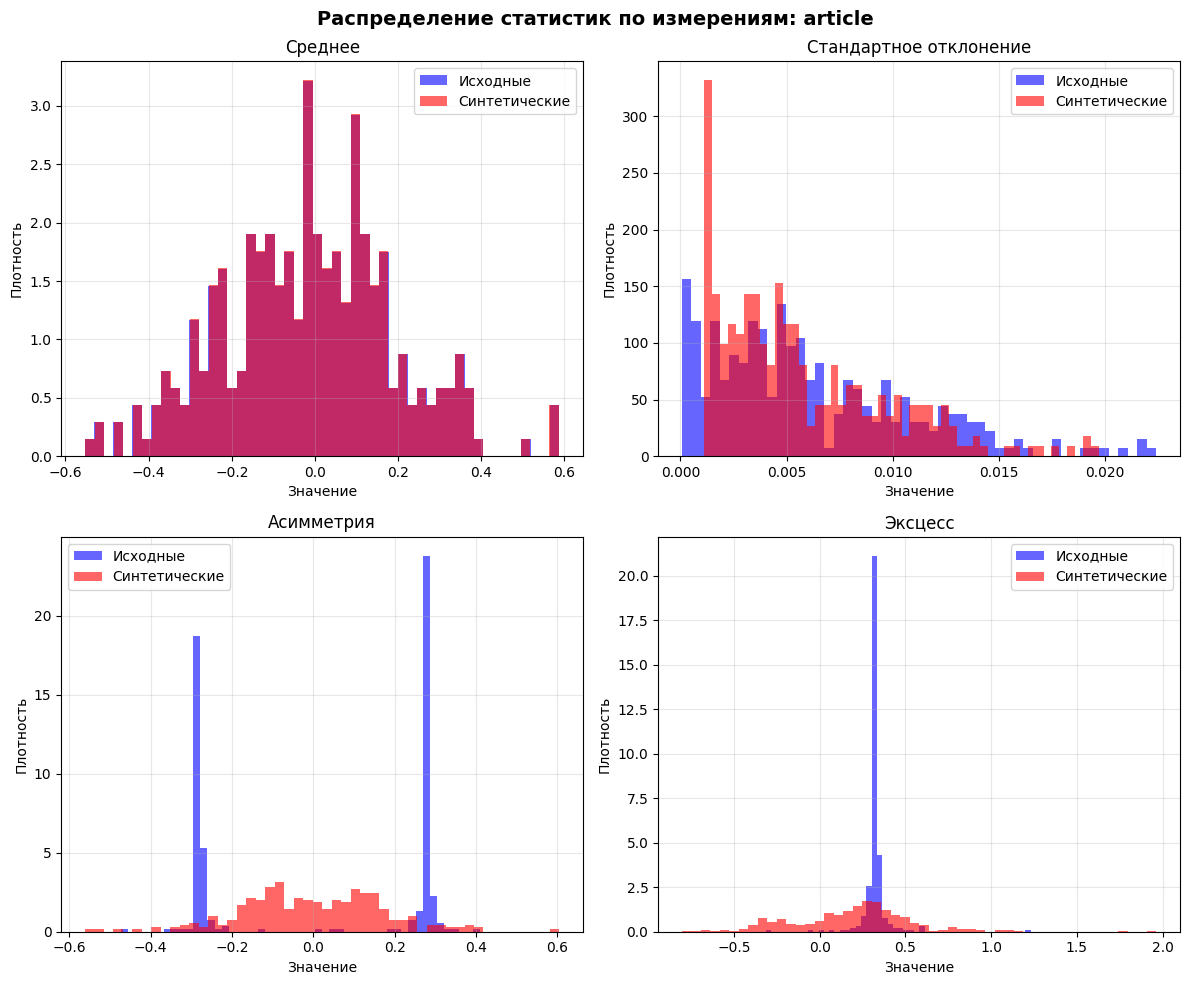

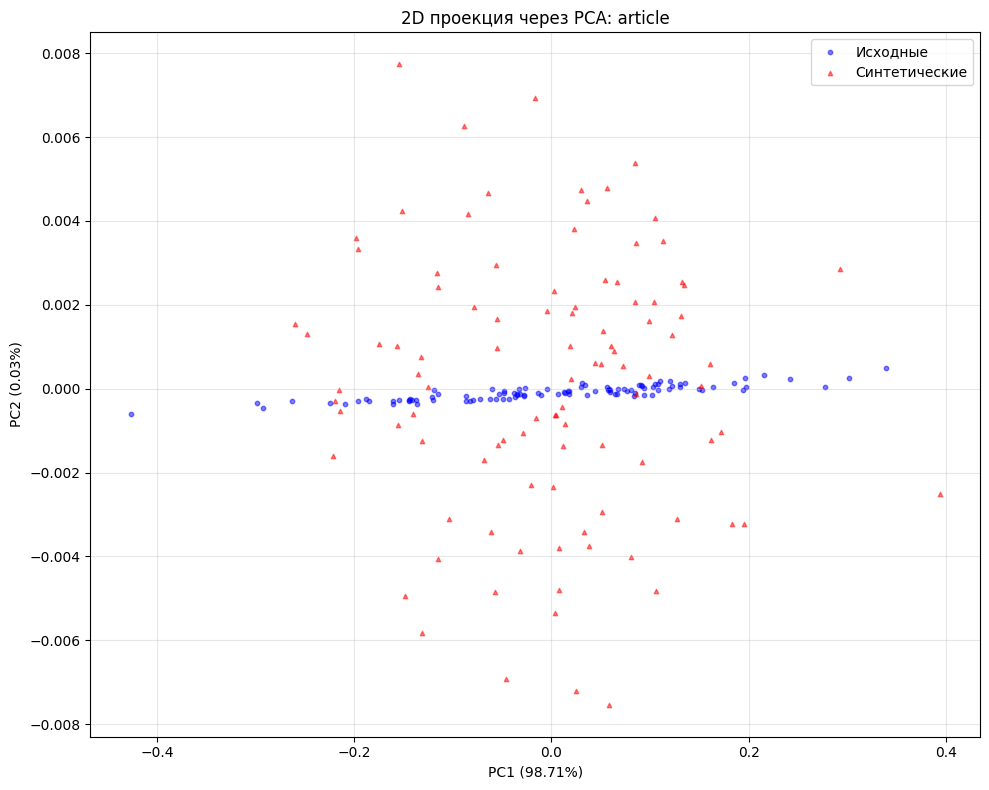

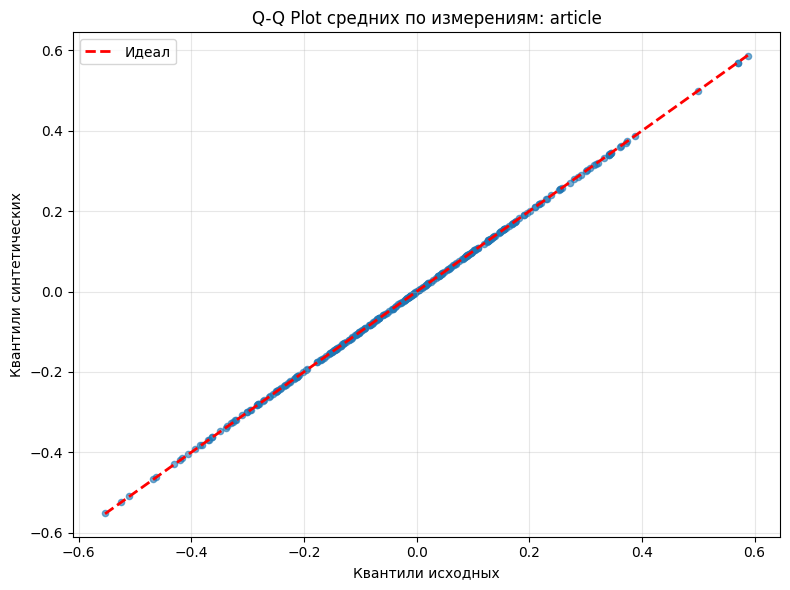

In [25]:
method = 'covariance_lw'

try:
    synthetic_data_cov = generate_synthetic_vectors(summary_df, method=method)
    validation_df_cov = validate_synthetic_data(synthetic_data_cov)
    print(validation_df_cov[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])
    visualize_distributions(synthetic_data_cov, features_data,
                           column_name=synthetic_data_cov[0]['column'])

except Exception as e:
    print(f"{e}")
    import traceback
    traceback.print_exc()